<a href="https://colab.research.google.com/github/kwamelevi07-cyber/DI_BOOTCAMP/blob/main/Exercises_XP_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Solution de l'Exercice : Introduction aux LLMs

## Exercice 1 : Chargement du Modèle

In [10]:
# Installation des bibliothèques nécessaires : transformers pour les modèles, matplotlib pour les graphiques
%pip install --quiet transformers matplotlib --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 88.1 MB/s eta 0:00:00


In [11]:
# Importation des composants pour charger le modèle et le tokenizer
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
# Importation de torch pour la gestion du calcul tensoriel
import torch
# Importation de matplotlib pour la visualisation
import matplotlib.pyplot as plt
# Importation pour gérer et ignorer les messages d'avertissement
import warnings
# Configuration pour masquer les avertissements non essentiels
warnings.filterwarnings("ignore")

# Définition du nom du modèle pré-entraîné à utiliser (GPT-2)
model_name = 'gpt2'
# Chargement du tokenizer associé au modèle GPT-2 pour transformer le texte en nombres
tokenizer = AutoTokenizer.from_pretrained(model_name)
# Chargement du modèle de langage causal GPT-2 lui-même
model = AutoModelForCausalLM.from_pretrained(model_name)

# Affichage d'un message de confirmation une fois le chargement terminé
print(f"\nModèle '{model_name}' chargé avec succès !")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


Modèle 'gpt2' chargé avec succès !


## Exercice 2 : Tokenisation et Visualisation

Texte original : L'intelligence artificielle transforme notre compréhension du langage.
Tokens : ['L', "'", 'intelligence', 'Ġartific', 'iel', 'le', 'Ġtransform', 'e', 'Ġnot', 're', 'Ġcompr', 'Ã©', 'hens', 'ion', 'Ġdu', 'Ġlang', 'age', '.']
IDs de Tokens : [43, 6, 32683, 29829, 8207, 293, 6121, 68, 407, 260, 12084, 2634, 5135, 295, 7043, 42392, 496, 13]


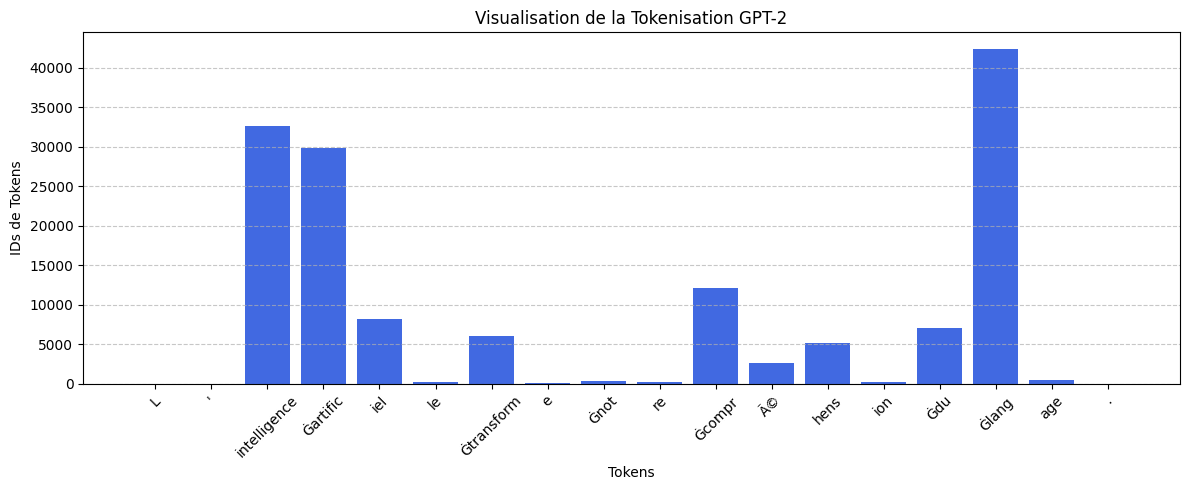

In [12]:
# Définition de la phrase d'exemple pour l'analyse
text = "L'intelligence artificielle transforme notre compréhension du langage."

# Découpage de la phrase en unités élémentaires appelées 'tokens'
tokens = tokenizer.tokenize(text)
# Conversion de ces tokens en leurs identifiants numériques respectifs dans le vocabulaire du modèle
token_ids = tokenizer.convert_tokens_to_ids(tokens)

# Affichage du texte original
print(f"Texte original : {text}")
# Affichage de la liste des tokens générés
print(f"Tokens : {tokens}")
# Affichage de la liste des IDs correspondants
print(f"IDs de Tokens : {token_ids}")

# Définition de l'étiquette de l'axe horizontal
x_label = "Tokens"
# Définition de l'étiquette de l'axe vertical
y_label = "IDs de Tokens"
# Définition du titre du graphique
title = "Visualisation de la Tokenisation GPT-2"

# Création d'une figure avec des dimensions spécifiques
plt.figure(figsize=(12, 5))
# Création d'un graphique en barres avec les IDs de tokens en hauteur
plt.bar(range(len(tokens)), token_ids, color="royalblue")
# Application du nom de l'axe X
plt.xlabel(x_label)
# Application du nom de l'axe Y
plt.ylabel(y_label)
# Application du titre au graphique
plt.title(title)
# Configuration des graduations de l'axe X pour afficher le nom de chaque token avec une rotation
plt.xticks(range(len(tokens)), tokens, rotation=45)
# Ajout d'une grille horizontale pour faciliter la lecture des valeurs
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Ajustement automatique des marges pour éviter les coupures
plt.tight_layout()
# Affichage final du graphique
plt.show()

## Exercice 3 : Correspondance des IDs

In [13]:
# En-tête pour la section de correspondance
print("Correspondance des Tokens et IDs :\n")
# Boucle sur les deux listes en simultané pour associer chaque token à son ID
for token, token_id in zip(tokens, token_ids):
    # Affichage formaté : le token aligné à gauche et son ID numérique
    print(f"Token: {token:<15} | ID: {token_id}")

Correspondance des Tokens et IDs :

Token: L               | ID: 43
Token: '               | ID: 6
Token: intelligence    | ID: 32683
Token: Ġartific        | ID: 29829
Token: iel             | ID: 8207
Token: le              | ID: 293
Token: Ġtransform      | ID: 6121
Token: e               | ID: 68
Token: Ġnot            | ID: 407
Token: re              | ID: 260
Token: Ġcompr          | ID: 12084
Token: Ã©              | ID: 2634
Token: hens            | ID: 5135
Token: ion             | ID: 295
Token: Ġdu             | ID: 7043
Token: Ġlang           | ID: 42392
Token: age             | ID: 496
Token: .               | ID: 13


## Exercice 4 : Génération de Texte

In [14]:
# Initialisation du pipeline de génération de texte avec le modèle et le tokenizer chargés
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    # Utilisation du GPU si disponible (device 0), sinon du CPU (-1)
    device=0 if torch.cuda.is_available() else -1,
)

# Phrase de départ (amorce) fournie au modèle
input_text = "L'avenir de l'apprentissage automatique repose sur"

# Configuration des paramètres de génération
gen_kwargs = {
    # Nombre maximum de nouveaux tokens à générer après l'amorce
    "max_new_tokens": 50,
    # Contrôle du degré de créativité (plus élevé = plus aléatoire)
    "temperature": 0.7,
    # Filtrage nucléaire : garde uniquement les tokens dont la probabilité cumulée atteint top_p
    "top_p": 0.9,
    # Activation de l'échantillonnage aléatoire plutôt que de choisir toujours le plus probable
    "do_sample": True,
    # Définition du token de fin de séquence pour éviter les erreurs de complétion
    "pad_token_id": tokenizer.eos_token_id
}

# Appel du modèle pour générer la suite du texte
output = generator(input_text, **gen_kwargs)
# Affichage de l'amorce de départ
print(f"Entrée : {input_text}")
# Affichage du texte complet incluant la génération produite par l'IA
print(f"Sortie générée : {output[0]['generated_text']}")

[transformers] Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Entrée : L'avenir de l'apprentissage automatique repose sur
Sortie générée : L'avenir de l'apprentissage automatique repose sur la voix de la même dans la même.

I do not know whether the king of France would have been able to get his army to the place of the king of England, or if the king of France would
